In [25]:
import pandas as pd

In [26]:
all_factor=pd.read_csv("第一节代码导出的数据.csv")

In [27]:
all_factor = all_factor.reset_index(drop=True)

In [28]:
all_factor.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2430 entries, 0 to 2429
Data columns (total 20 columns):
Unnamed: 0                     2430 non-null int64
time                           2430 non-null object
code                           2430 non-null object
close                          2430 non-null float64
日内收益率                          2430 non-null float64
volume                         2430 non-null float64
turnover_ratio                 2430 non-null float64
pe_ratio                       2430 non-null float64
pb_ratio                       2430 non-null float64
ps_ratio                       2430 non-null float64
pcf_ratio                      2430 non-null float64
roe                            2430 non-null float64
net_profit_margin              2430 non-null float64
inc_net_profit_year_on_year    2430 non-null float64
net_operate_cash_flow          2430 non-null float64
circulating_market_cap         2430 non-null float64
1M                             2420 non-null floa

In [29]:
# 筛选需要的因子+标签列，重置索引、剔除全空行
split_factor = all_factor[["time", "code", "turnover_ratio", "1M", "5M", "10M"]].reset_index(drop=True)
split_factor = split_factor.dropna()

# 筛选样本时间区间：2014-01-31 ~ 2020-01-31
split_factor = split_factor[(split_factor["time"]<="2025-12-20")&(split_factor["time"]>="2025-01-10")]

# 初始化3个空表，分别存放每期分组的1M/5M/10M平均收益
all_one_M = pd.DataFrame()
all_five_M = pd.DataFrame()
all_ten_M = pd.DataFrame()

# 按每个交易日（横截面Date）循环，月度分层
for t in split_factor["time"].unique():
    split_t = split_factor[split_factor["time"]==t]
    # data_cut = pd.cut(split_t["净资产收益率(加权)"],5)  # 注释：等宽分组（废弃）
    # 因子分层：先rank排名、再qcut等分为5组（多因子标准分层）
    data_cut = pd.qcut(split_t["turnover_ratio"].rank(method="first"),5)
    
    # 按5个分组，分别计算每组未来1/5/10期收益率均值
    one_M = split_t["1M"].groupby(data_cut).mean()
    five_M = split_t["5M"].groupby(data_cut).mean()
    ten_M = split_t["10M"].groupby(data_cut).mean()
    
    # print(one_M) # 注释：打印单期分层结果
    
    # 把分组索引改成1~5（五分位：1组低分，5组高分）
    one_M.index = [1, 2, 3, 4, 5]
    five_M.index = [1, 2, 3, 4, 5]
    ten_M.index = [1, 2, 3, 4, 5]
    
    # 逐月拼接汇总所有横截面数据
    all_one_M = all_one_M.append(one_M)
    all_five_M = all_five_M.append(five_M)
    all_ten_M = all_ten_M.append(ten_M)

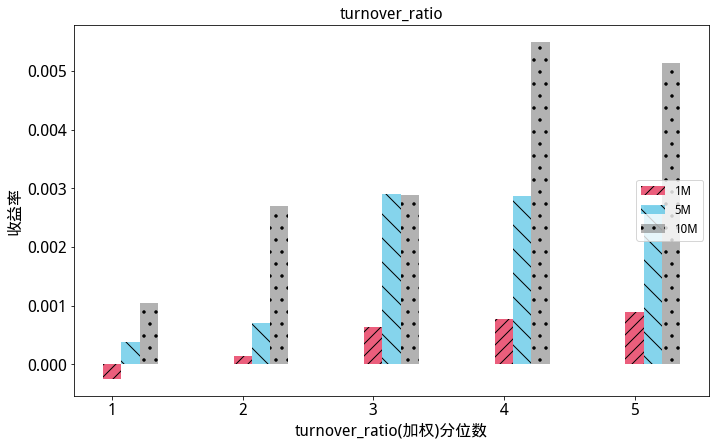

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# 解决中文和负号显示
plt.rcParams['font.sans-serif'] = ['SimHei']    # 替换sans-serif字体
plt.rcParams['axes.unicode_minus'] = False      # 解决坐标轴负数的负号显示问题

width = 0.14
legends = ["1M", "5M", "10M"]
plt.figure(figsize=(10, 6))
plt.subplot()

FONT_SIZE = 16
plt.rc('font', size=FONT_SIZE)                  # fontsize of the text sizes
plt.rc('axes', titlesize=FONT_SIZE)             # fontsize of the axes title
plt.rc('axes', labelsize=FONT_SIZE)             # fontsize of the x and y labels
plt.rc('legend', fontsize=FONT_SIZE - 4)        # fontsize of the legend

x_axis_data = np.array([1, 2, 3, 4, 5])
# barh换成bar

# patterns = ('/', '//', '-', '+', 'x', '||', '|||', '*', 'o', '0', '.')
# 三组并列柱状图
plt.bar(x_axis_data, all_one_M.mean(), width, align='center', alpha=1, hatch="//", color='#eb5e7c')
plt.bar(x_axis_data + width, all_five_M.mean().values, width, align='center', alpha=0.6, hatch='\\',color='#34b8e0')
plt.bar(x_axis_data + 2*width, all_ten_M.mean().values, width, align='center', alpha=0.6, hatch='.',color='gray')

plt.tight_layout()

# x换成y
# plt.xticks(x_axis_data,year)
plt.xlabel("turnover_ratio(加权)分位数")
plt.ylabel("收益率")
# plt.x_labels(year)
# ll = plt.legend(["//", "-"], ["line 2", "line 1"], loc='upper left')
plt.legend(legends, loc="right")
plt.title("turnover_ratio")
# plt.savefig("results/净资产收益率分位数收益率.png",dpi=500, bbox_inches = 'tight')#解决图片不清晰，不完整的问题
plt.show()

In [54]:
df1=all_factor.copy()
df1=df1.drop(["Unnamed: 0","close","1M","3M","5M","10M"],axis=1)

df1.head()



,time,code,日内收益率,volume,turnover_ratio,pe_ratio,pb_ratio,ps_ratio,pcf_ratio,roe,net_profit_margin,inc_net_profit_year_on_year,net_operate_cash_flow,circulating_market_cap
0,2025-01-02,000001.XSHE,-0.026032,-2.256970,-2.112075,-1.565787,-0.063302,-0.074557,-1.354803,1.504460,1.638136,0.977693,-0.944657,1.731194
1,2025-01-02,000002.XSHE,-0.019310,0.531564,0.365432,0.487044,0.949528,1.495057,0.217562,0.802671,0.236440,0.658079,1.556820,-0.693255
2,2025-01-02,000063.XSHE,-0.060843,-0.785244,-0.811384,-1.022391,-1.139433,-0.702402,-0.887764,0.714947,1.283861,0.264707,-0.049719,0.706712
3,2025-01-02,000100.XSHE,-0.016064,-0.010651,-0.192007,-0.297862,-0.886226,-0.231518,-0.700948,-0.469321,0.167125,-0.653161,-0.447469,-0.350280
4,2025-01-02,000157.XSHE,-0.029499,0.918861,0.984809,1.231699,1.012830,0.396327,1.011529,0.057020,-0.918804,0.330269,0.537585,-1.021096


In [ ]:
# 筛选2017.01.31~2018.01.31区间数据
split_data = df1[(df1["time"]<="2025-12-20")&(df1["time"]>="2025-01-10")]

# 定义函数：计算月度IC序列（因子与下期收益相关系数）
def getICSeries(factors):
    icall = factors.groupby("time").apply(lambda x: x.corr()["日内收益率"]).reset_index()
    icall = icall.dropna().drop(["日内收益率"], axis=1).set_index("time")
    return icall

icall = getICSeries(split_data)

icall.head()
icall.info()

In [40]:
# 计算各因子|IC|>0.03的月份占比（IC胜率）
prob = []
for i in icall.columns:
    a = len(icall[abs(icall[i])>0.03])/len(icall)
    prob.append(a)

prob

[0.9126637554585153,
 0.9519650655021834,
 0.9301310043668122,
 0.9082969432314411,
 0.9519650655021834,
 0.9170305676855895,
 0.925764192139738,
 0.9344978165938864,
 0.9475982532751092,
 0.9170305676855895,
 0.9388646288209607]

In [56]:
# 因子收益率（横截面OLS回归求因子收益）
from sklearn.linear_model import LinearRegression
import numpy as np

count = 0
for t in split_data["time"].unique():
    T_data = split_data[split_data["time"]==t]
    X_standard = T_data.iloc[:,3:14].values   # 自变量：全部因子列
    y = T_data.iloc[:,2].values             # 因变量：下期收益next_ret
    model = LinearRegression(fit_intercept=False).fit(X_standard, y)
    
    if count == 0:
        OLS_ret = model.coef_
    else:
        OLS_ret += model.coef_
    count += 1
    
OLS_ret

array([-160.826932050261, 768.8092371303027, -16.917249857072086,
       282.00970457990474, 63.68106925540591, -177.2834201791547,
       -422.95368976803815, -254.66291676898928, 789.4213477078639,
       305.1754879210765, 116.73305240364424])

In [57]:
metrics = pd.DataFrame()
metrics["IC mean"] = icall.mean()
print(metrics)




                              IC mean
日内收益率                                
volume                      -0.039618
turnover_ratio              -0.046307
pe_ratio                     0.045379
pb_ratio                     0.066821
ps_ratio                     0.038320
pcf_ratio                   -0.003367
roe                          0.053097
net_profit_margin            0.019165
inc_net_profit_year_on_year  0.052576
net_operate_cash_flow        0.006931
circulating_market_cap       0.022838


In [58]:
metrics["IC std"] = icall.std()

metrics["IR"] = icall.mean()/icall.std()
metrics["abs(IC)>0.03"] = prob

metrics
# metrics.to_csv("2011.csv")

,IC mean,IC std,IR,abs(IC)>0.03
日内收益率,,,,
volume,-0.039618,0.297125,-0.133340,0.912664
turnover_ratio,-0.046307,0.308707,-0.150002,0.951965
pe_ratio,0.045379,0.321280,0.141243,0.930131
pb_ratio,0.066821,0.304163,0.219690,0.908297
ps_ratio,0.038320,0.363698,0.105361,0.951965
pcf_ratio,-0.003367,0.325378,-0.010348,0.917031
roe,0.053097,0.297513,0.178470,0.925764
net_profit_margin,0.019165,0.378580,0.050623,0.934498
inc_net_profit_year_on_year,0.052576,0.326218,0.161168,0.947598


In [59]:
metrics["因子收益率均值"] = OLS_ret/100
metrics

,IC mean,IC std,IR,abs(IC)>0.03,因子收益率均值
日内收益率,,,,,
volume,-0.039618,0.297125,-0.133340,0.912664,-1.608269
turnover_ratio,-0.046307,0.308707,-0.150002,0.951965,7.688092
pe_ratio,0.045379,0.321280,0.141243,0.930131,-0.169172
pb_ratio,0.066821,0.304163,0.219690,0.908297,2.820097
ps_ratio,0.038320,0.363698,0.105361,0.951965,0.636811
pcf_ratio,-0.003367,0.325378,-0.010348,0.917031,-1.772834
roe,0.053097,0.297513,0.178470,0.925764,-4.229537
net_profit_margin,0.019165,0.378580,0.050623,0.934498,-2.546629
inc_net_profit_year_on_year,0.052576,0.326218,0.161168,0.947598,7.894213


In [60]:
# 筛选IC均值绝对值大于0.03的因子
split_metrics = metrics[abs(metrics["IC mean"]) > 0.03]
# 按照IR升序排序（如需降序加 ascending=False）
split_metrics = split_metrics.sort_values(by=["IR"])

In [61]:
split_metrics

,IC mean,IC std,IR,abs(IC)>0.03,因子收益率均值
日内收益率,,,,,
turnover_ratio,-0.046307,0.308707,-0.150002,0.951965,7.688092
volume,-0.039618,0.297125,-0.133340,0.912664,-1.608269
ps_ratio,0.038320,0.363698,0.105361,0.951965,0.636811
pe_ratio,0.045379,0.321280,0.141243,0.930131,-0.169172
inc_net_profit_year_on_year,0.052576,0.326218,0.161168,0.947598,7.894213
roe,0.053097,0.297513,0.178470,0.925764,-4.229537
pb_ratio,0.066821,0.304163,0.219690,0.908297,2.820097


In [1]:
# 画图二
import matplotlib.pyplot as plt
import seaborn as sns
# sns.set()
plt.rcParams['font.sans-serif'] = ['SimHei']   # 步骤一（替换sans-serif字体）
plt.rcParams['axes.unicode_minus'] = False     # 步骤二（解决坐标轴负数的负号显示问题）

# ========== 图1：因子收益率均值 ==========
trans = split_metrics.T
fig = plt.figure(figsize = (10,5))
trans.iloc[4].plot(kind = 'bar')
trans.iloc[4].plot(kind = 'line',color = 'darkred',linewidth = 2)
plt.xlabel("因子")
plt.title('因子收益率均值')
plt.savefig("results/因子收益率均值.png",dpi=500,bbox_inches = 'tight')#解决图片不清晰，不完整的问题

# ========== 图2：因子IR ==========
trans = split_metrics.T
fig = plt.figure(figsize = (10,5))
trans.iloc[2].plot(kind = 'bar')
trans.iloc[2].plot(kind = 'line',color = 'darkred',linewidth = 2)
plt.xlabel("因子")
plt.title('因子IR')
plt.savefig("results/因子IR.png",dpi=500,bbox_inches = 'tight')#解决图片不清晰，不完整的问题

# ========== 图3：abs(IC)>0.03 ==========
trans = split_metrics.T
fig = plt.figure(figsize = (10,5))
trans.iloc[3].plot(kind = 'bar')
trans.iloc[3].plot(kind = 'line',color = 'darkred',linewidth = 2)
plt.title('abs(IC)>0.03')
plt.xlabel("因子")
plt.savefig("results/abs(IC)_0.03.png",dpi=500,bbox_inches = 'tight')#解决图片不清晰，不完整的问题

NameError: name 'split_metrics' is not defined